In [1]:
import os
os.environ['KAGGLE_USERNAME'] = 'aliaanasserr'
os.environ['KAGGLE_KEY'] = "44c0be04c2fc2fdf79f2bd7145f9012d"

import kaggle
kaggle.api.authenticate()

kaggle.api.dataset_download_files(
    'emmarex/plantdisease',
    path='./data',
    unzip=True
)

print("Dataset downloaded")


Dataset URL: https://www.kaggle.com/datasets/emmarex/plantdisease
Dataset downloaded


In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import json
warnings.filterwarnings('ignore')

from PIL import Image
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

np.random.seed(42)
tf.random.set_seed(42)

In [9]:
classes = sorted(os.listdir('./data/PlantVillage'))
num_classes = len(classes)

print(f'Number of classes: {num_classes}')
class_counts = {}
for cls in classes:
    count = len(os.listdir(os.path.join('./data/PlantVillage', cls)))
    class_counts[cls] = count
    print(f'  {cls}: {count} images')

print(f'Total images: {sum(class_counts.values())}')

Number of classes: 15
  Pepper__bell___Bacterial_spot: 997 images
  Pepper__bell___healthy: 1478 images
  Potato___Early_blight: 1000 images
  Potato___Late_blight: 1000 images
  Potato___healthy: 152 images
  Tomato_Bacterial_spot: 2127 images
  Tomato_Early_blight: 1000 images
  Tomato_Late_blight: 1909 images
  Tomato_Leaf_Mold: 952 images
  Tomato_Septoria_leaf_spot: 1771 images
  Tomato_Spider_mites_Two_spotted_spider_mite: 1676 images
  Tomato__Target_Spot: 1404 images
  Tomato__Tomato_YellowLeaf__Curl_Virus: 3209 images
  Tomato__Tomato_mosaic_virus: 373 images
  Tomato_healthy: 1591 images
Total images: 20639


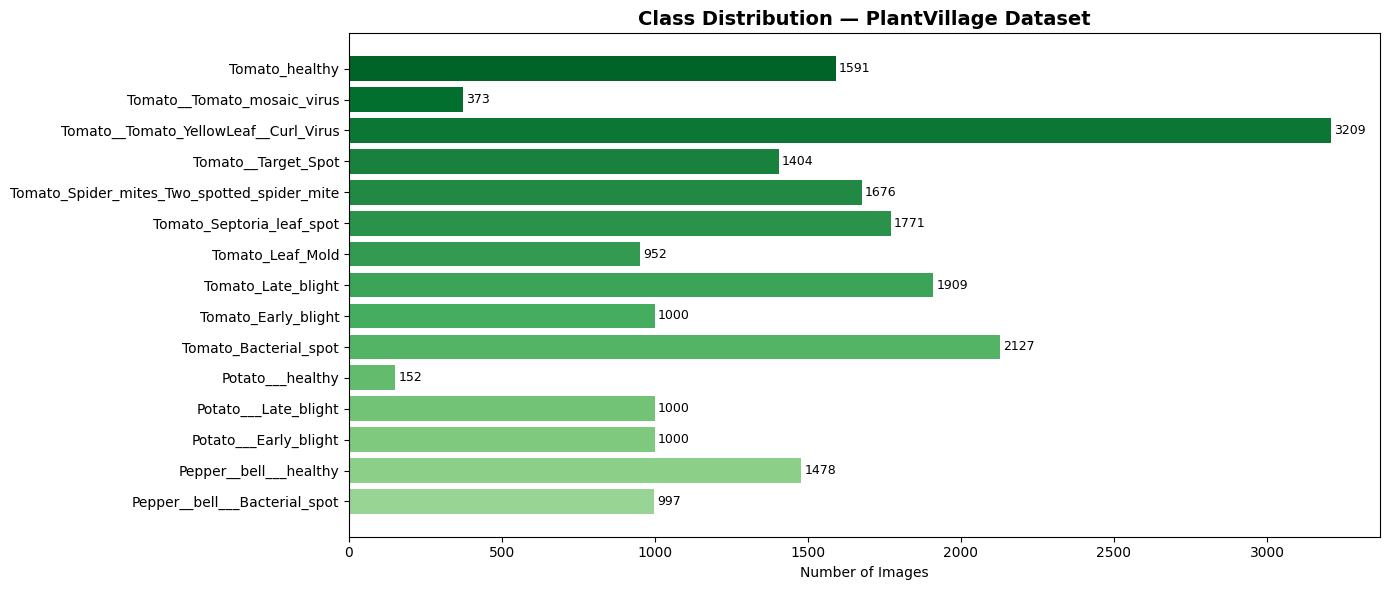

In [10]:
plt.figure(figsize=(14, 6))
bars = plt.barh(list(class_counts.keys()), list(class_counts.values()),
                color=plt.cm.Greens(np.linspace(0.4, 0.9, num_classes)))
plt.xlabel('Number of Images')
plt.title('Class Distribution — PlantVillage Dataset', fontsize=14, fontweight='bold')
for bar, val in zip(bars, class_counts.values()):
    plt.text(val + 10, bar.get_y() + bar.get_height()/2, str(val), va='center', fontsize=9)
plt.tight_layout()
plt.show()

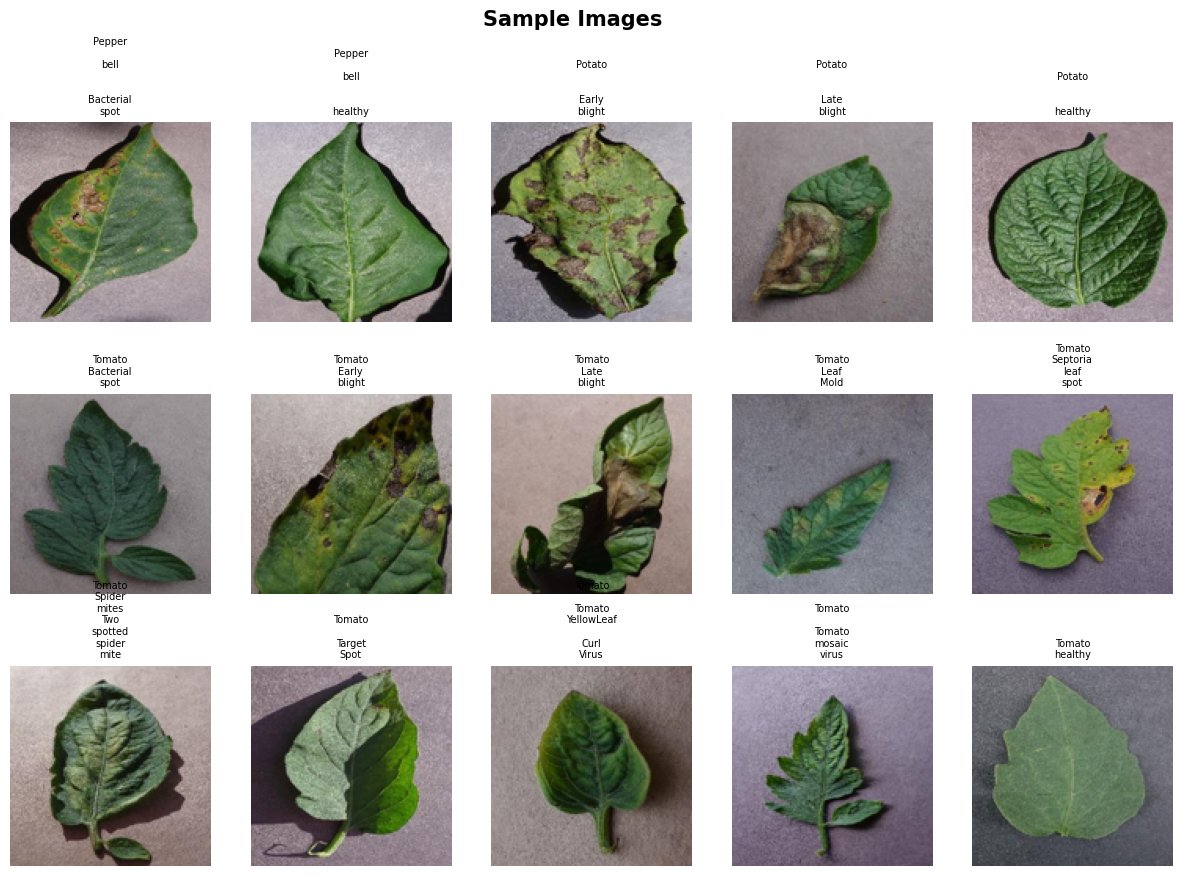

In [18]:
fig, axes = plt.subplots(3, 5, figsize=(15, 10))
axes = axes.flatten()

for i, cls in enumerate(classes):
    cls_dir = os.path.join('./data/PlantVillage', cls)
    img_file = os.listdir(cls_dir)[0]
    img = Image.open(os.path.join(cls_dir, img_file)).resize((128, 128))
    axes[i].imshow(img)
    axes[i].set_title(cls.replace('_', '\n'), fontsize=7)
    axes[i].axis('off')

plt.suptitle('Sample Images', fontsize=15, fontweight='bold')
plt.show()

In [19]:
IMG_SIZE   = (128, 128)
BATCH_SIZE = 32

#Augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1,
    validation_split=0.2      #20%
)

#No augmentation for validation and test sets, only rescaling
test_datagen = ImageDataGenerator(rescale=1./255) 


In [20]:
train_generator = train_datagen.flow_from_directory(
    './data/PlantVillage',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

Found 16516 images belonging to 15 classes.


In [21]:
val_generator = train_datagen.flow_from_directory(
    './data/PlantVillage',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

Found 4122 images belonging to 15 classes.


In [22]:
class_names = list(train_generator.class_indices.keys())
print(f'Training samples:   {train_generator.samples}')
print(f'Validation samples: {val_generator.samples}')
print(f'Number of classes:  {num_classes}')

Training samples:   16516
Validation samples: 4122
Number of classes:  15


In [23]:
def build_cnn_model(input_shape, num_classes):
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape),
        BatchNormalization(),
        MaxPooling2D(2, 2),
        Dropout(0.25),

        Conv2D(64, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2, 2),
        Dropout(0.25),

        Conv2D(128, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2, 2),
        Dropout(0.3),

        Conv2D(256, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2, 2),
        Dropout(0.3),

        Flatten(),
        Dense(512, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [24]:
input_shape = (IMG_SIZE[0], IMG_SIZE[1], 3)
model = build_cnn_model(input_shape, num_classes)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     8,389,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │         7,695 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,789,199 (33.53 MB)

 Trainable params: 8,787,215 (33.52 MB)

 Non-trainable params: 1,984 (7.75 KB)

In [25]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint('plant_disease_model.keras', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
]

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=30,
    callbacks=callbacks
)

Epoch 1/30
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5309 - loss: 1.5846
Epoch 1: val_loss improved from None to 3.31432, saving model to plant_disease_model.keras

Epoch 1: finished saving model to plant_disease_model.keras
517/517 ━━━━━━━━━━━━━━━━━━━━ 798s 2s/step - accuracy: 0.6174 - loss: 1.2247 - val_accuracy: 0.3042 - val_loss: 3.3143 - learning_rate: 0.0010
Epoch 2/30
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 935ms/step - accuracy: 0.7637 - loss: 0.7269
Epoch 2: val_loss improved from 3.31432 to 0.94066, saving model to plant_disease_model.keras

Epoch 2: finished saving model to plant_disease_model.keras
517/517 ━━━━━━━━━━━━━━━━━━━━ 512s 970ms/step - accuracy: 0.7680 - loss: 0.7017 - val_accuracy: 0.7203 - val_loss: 0.9407 - learning_rate: 0.0010
Epoch 3/30
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 422ms/step - accuracy: 0.8069 - loss: 0.5696
Epoch 3: val_loss did not improve from 0.94066
517/517 ━━━━━━━━━━━━━━━━━━━━ 235s 455ms/step - accuracy: 0.8126 - loss: 0.5554 - val_accuracy: 0.2

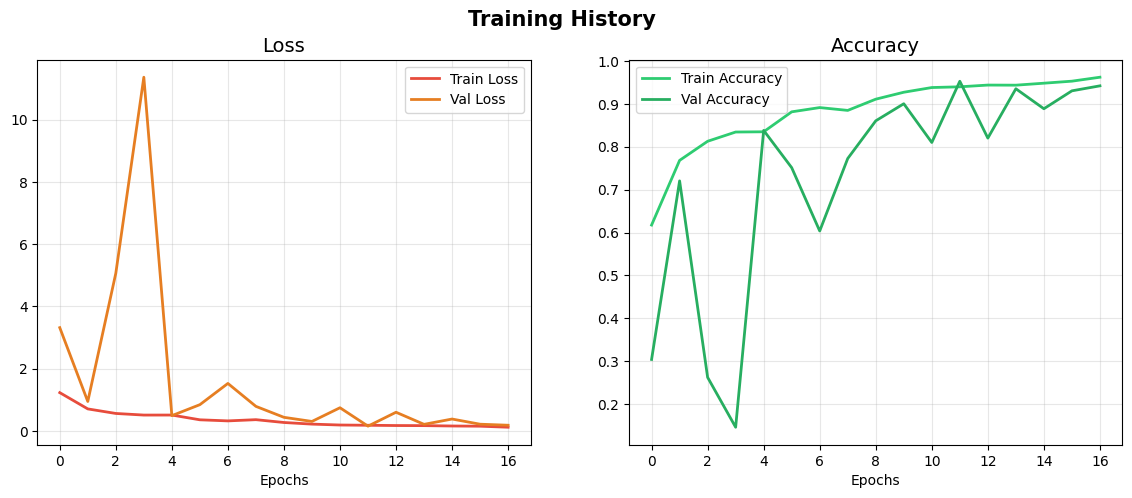

In [33]:
hist = pd.DataFrame(history.history)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(hist['loss'],     label='Train Loss',     color='#e74c3c', linewidth=2)
axes[0].plot(hist['val_loss'], label='Val Loss',       color='#e67e22', linewidth=2)
axes[0].set_title('Loss',     fontsize=14)
axes[0].set_xlabel('Epochs')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(hist['accuracy'],     label='Train Accuracy', color='#2ecc71', linewidth=2)
axes[1].plot(hist['val_accuracy'], label='Val Accuracy',   color='#27ae60', linewidth=2)
axes[1].set_title('Accuracy',      fontsize=14)
axes[1].set_xlabel('Epochs')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Training History', fontsize=15, fontweight='bold')
plt.show()

In [29]:
val_generator.reset()
y_pred_probs = model.predict(val_generator)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = val_generator.classes

acc = accuracy_score(y_true, y_pred)
print(f'Validation Accuracy: {acc:.4f} ({acc*100:.2f}%)')
print()
print('Classification Report:')
print(classification_report(y_true, y_pred, target_names=class_names))

129/129 ━━━━━━━━━━━━━━━━━━━━ 27s 208ms/step
Validation Accuracy: 0.9546 (95.46%)

Classification Report:
                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.97      0.94      0.96       199
                     Pepper__bell___healthy       0.94      1.00      0.97       295
                      Potato___Early_blight       0.93      0.99      0.96       200
                       Potato___Late_blight       0.92      0.97      0.94       200
                           Potato___healthy       0.96      0.77      0.85        30
                      Tomato_Bacterial_spot       0.91      1.00      0.95       425
                        Tomato_Early_blight       0.98      0.75      0.85       200
                         Tomato_Late_blight       0.95      0.95      0.95       381
                           Tomato_Leaf_Mold       0.99      0.97      0.98       190
                  Tomato_Septoria_leaf_spot 

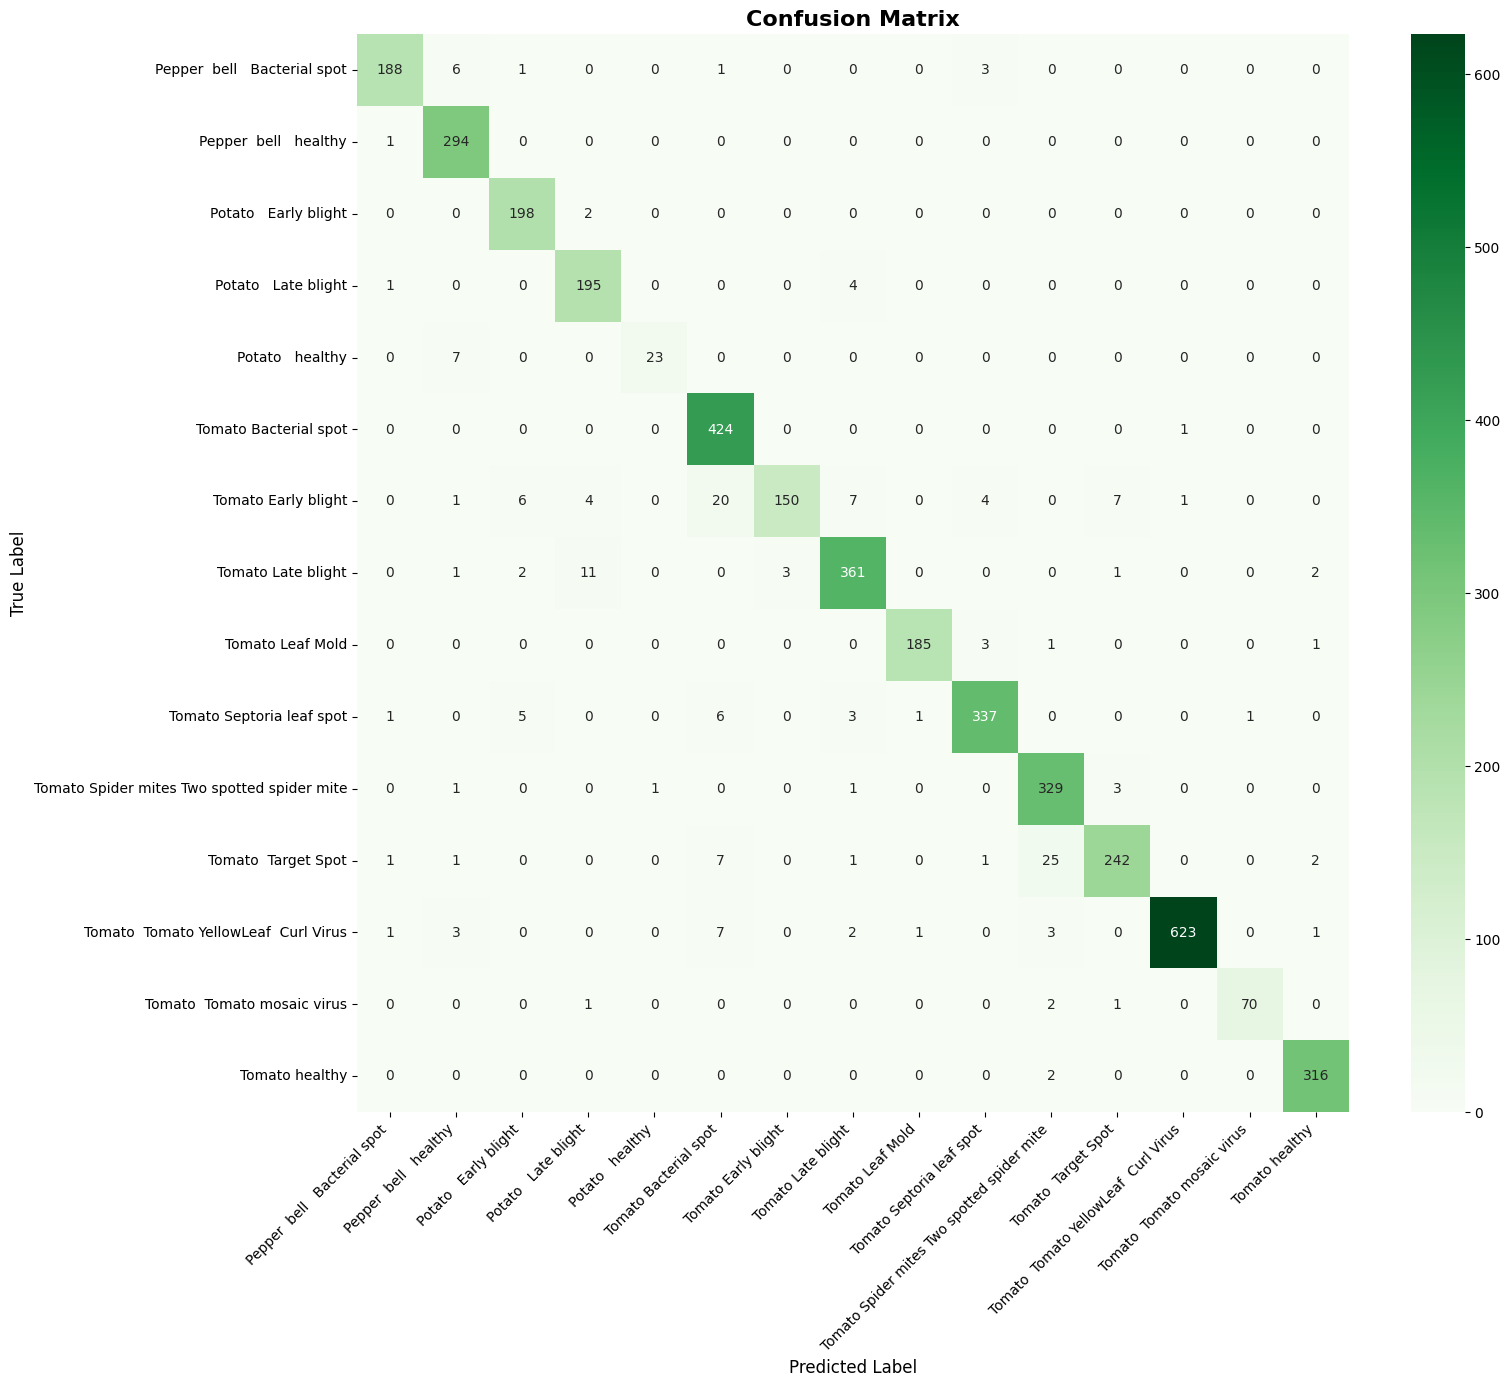

In [32]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(16, 14))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=[c.replace('_', ' ') for c in class_names],
            yticklabels=[c.replace('_', ' ') for c in class_names])
plt.title('Confusion Matrix', fontsize=16, fontweight='bold')
plt.ylabel('True Label',      fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.show()

### 1. The Golden Diagonal
    The dark green squares running diagonally from the top-left to the bottom-right represent the correct predictions.
    For example, the number 623 for Tomato Yellow Leaf Curl means the model successfully identified that many images correctly.
    A darker and more populated diagonal indicates a stronger and more accurate model.

### 2. Reading the "Confusion"
    Numbers outside the dark green diagonal represent errors.
    Looking at the Tomato Target Spot row, the model predicted 242 images correctly.
    However, in the same row, there is a value of 25 under the Tomato Spider mites column.
    This means the model mistakenly identified "Target Spot" as "Spider mites" 25 times, likely because both diseases produce similar-looking leaf spots.

### 3. Axis Analysis
    True Label (Vertical Axis): This is the "Ground Truth" or the actual label assigned to the image folder.
    Predicted Label (Horizontal Axis): This is the "Model's Opinion" after analyzing the image.

### 4. Key Observations
    Strongest Class: Tomato Yellow Leaf Curl Virus (623) is highly accurate because the curly, yellow leaf pattern is very distinct.
    Weakest Class: Potato healthy (23) shows some confusion with Pepper bell healthy (7 errors), suggesting that healthy green leaves across different species can look very similar at this resolution.
    Tomato Complexity: Significant overlap exists between different tomato diseases (like Bacterial spot and Early blight) because their visual symptoms are closely related.

In [35]:
with open('class_names.json', 'w') as f:
    json.dump(class_names, f)
print(class_names)

['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']
